<a href="https://colab.research.google.com/github/J-cuerora/SE-ALES-Y-SISTEMAS/blob/main/25_DE_NOVIEMBRE_SLIT2OrdenCanonicoLaplace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solución de SLIT segundo orden forma canónica utilizando transformada de Laplace en Sympy
Aplicación de fracciones parciales

In [ ]:
!pip install sympy --upgrade #actualizar sympy para usar módulo de control

In [ ]:
import sympy as sym
import matplotlib.pyplot as plt
import numpy as np
sym.init_printing()

s = sym.symbols('s', complex=True)
t,R, L, C = sym.symbols('t R L C', positive=True, real=True)

#Entrada de interés en Laplace
X = 1 # X(s) = 1 Respuesta entrada impulso; X(s) = 1/s resp escalón, X(s) = 1/s**2 resp a la rampa
#Forma canónica -> resolver según sistema propuesto
K = 1 #ganancia estática
wn = sym.sqrt(1/(C*L)) #frecuencia natural
xi = L/(2*R*sym.sqrt(C*L)) #factor amortiguamiento
H = K*(wn**2/(s**2 + 2*xi*wn*s + wn**2)) #función de transferencia en lazo cerrado slit 2 orden
#Hlc = H/(1+H) #para lazo cerrado
H

         1          
────────────────────
    ⎛ 2    s     1 ⎞
C⋅L⋅⎜s  + ─── + ───⎟
    ⎝     C⋅R   C⋅L⎠

In [ ]:
#calcular polos
p1 = -xi*wn + 1j*wn*sym.sqrt(1-xi**2)
p2 = -xi*wn - 1j*wn*sym.sqrt(1-xi**2)
p1

                     ____________
                    ╱       L    
          1.0⋅ⅈ⋅   ╱  1 - ────── 
                  ╱            2 
    1           ╲╱        4⋅C⋅R  
- ───── + ───────────────────────
  2⋅C⋅R            √C⋅√L         

In [ ]:
#evaluar valores RLC
RLC = {R: 1, L: sym.Rational('0.5'), C: sym.Rational('0.4')}#valores utilizados para la simulación
H.subs(RLC)

     5      
────────────
 2   5⋅s    
s  + ─── + 5
      2     

In [ ]:
print('p1=',p1.subs(RLC))
print('p2=',p2.subs(RLC))
print('xi=',xi.subs(RLC))
print('omega_n=',wn.subs(RLC))

p1= -5/4 + 0.25*sqrt(55)*I
p2= -5/4 - 0.25*sqrt(55)*I
xi= sqrt(5)/4
omega_n= sqrt(5)


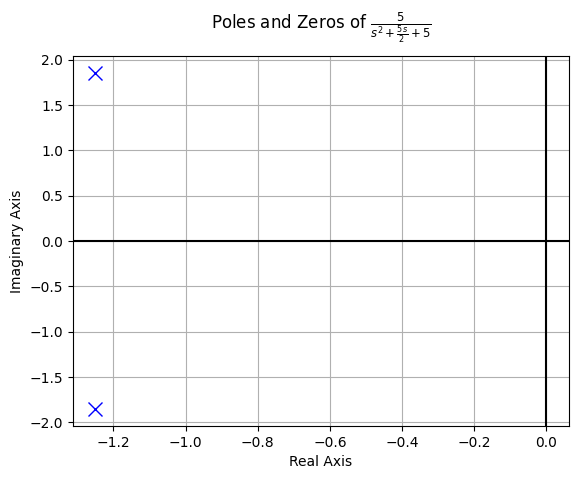

In [ ]:
#gráfica polos y ceros paquete de control de sympy
from sympy.physics.control.lti import TransferFunction
from sympy.physics.control.control_plots import pole_zero_plot
num,den=sym.fraction(H.subs(RLC))

tf1 = TransferFunction(num, den, s)#numerados y denomirador función de transferencia con valores evaluados de RLC
pole_zero_plot(tf1)

In [ ]:
#salida según entrada de interés
Y = H * X #función de transferencia del circuito multiplicada por X(s)
#Función de salida
Y

         1          
────────────────────
    ⎛ 2    s     1 ⎞
C⋅L⋅⎜s  + ─── + ───⎟
    ⎝     C⋅R   C⋅L⎠

In [ ]:
#Función de salida en Laplace factorizada (fracciones parciales)
Yp = Y.apart(s) # el comando apart factoriza la expresión simbólica
Yp


        R         
──────────────────
       2          
C⋅L⋅R⋅s  + L⋅s + R

In [ ]:
#Modelo en el tiempo en función de RLC
Ye = Yp
#Se recorre cada fracción parcial según factorización para simplificar cálculos
for j in range(len(Ye.args)):
    if j==0:#primer elemento de la solucion
      yt = sym.inverse_laplace_transform(Ye.args[j], s, t)
    else: #siguientes elementos concatenados
      yt+= sym.inverse_laplace_transform(Ye.args[j], s, t)
yt

    -t      ⎛     ____________⎞
   ─────    ⎜    ╱      2     ⎟
   2⋅C⋅R    ⎜t⋅╲╱  4⋅C⋅R  - L ⎟
2⋅ℯ     ⋅sin⎜─────────────────⎟
            ⎝    2⋅C⋅√L⋅R     ⎠
───────────────────────────────
            ____________       
           ╱      2            
      √L⋅╲╱  4⋅C⋅R  - L        

In [ ]:
#Modelo en el tiempo en función de RLC - substituir valores
Ye = Yp.subs(RLC).apart(s)
Ye


      10       
───────────────
   2           
2⋅s  + 5⋅s + 10

In [ ]:
#Se recorre cada fracción parcial según factorización para simplificar cálculos
for j in range(len(Ye.args)):
    if j==0:#primer elemento de la solucion
      yt = sym.inverse_laplace_transform(Ye.args[j], s, t)
    else: #siguientes elementos concatenados
      yt+= sym.inverse_laplace_transform(Ye.args[j], s, t)
yt

       -5⋅t            
       ─────           
         4      ⎛√55⋅t⎞
2⋅√55⋅ℯ     ⋅sin⎜─────⎟
                ⎝  4  ⎠
───────────────────────
          55           

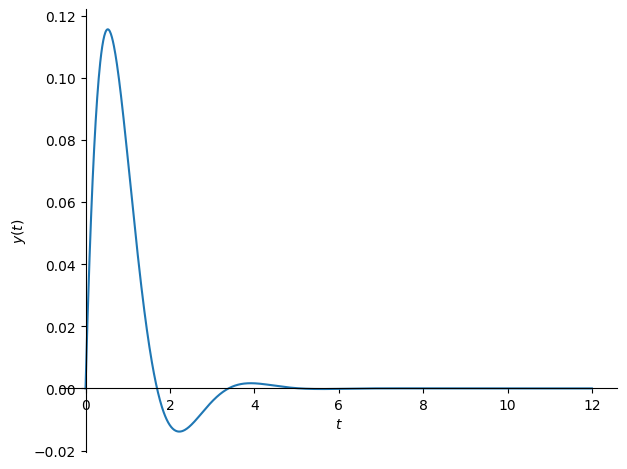

In [ ]:
#Gráfica de salida en el tiempo
sym.plot(yt,(t,0,float((3/xi*wn).subs(RLC))),xlabel='$t$', ylabel='$y(t)$')
plt.show()


EJERCICIO 25 DE NOVIEMBRE

Función de transferencia G(s) =
           1           
───────────────────────
         2             
2.16e-5⋅s  + 0.12⋅s + 1

Ceros del sistema: []
Polos del sistema: [-5547.20968458100, -8.34587097455163]


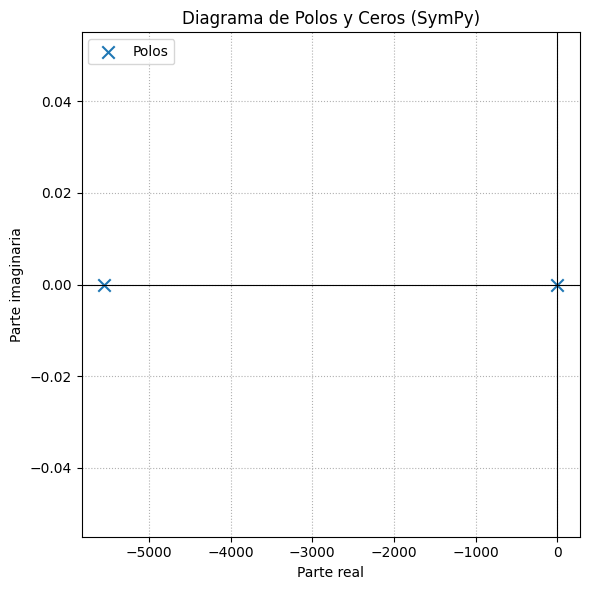

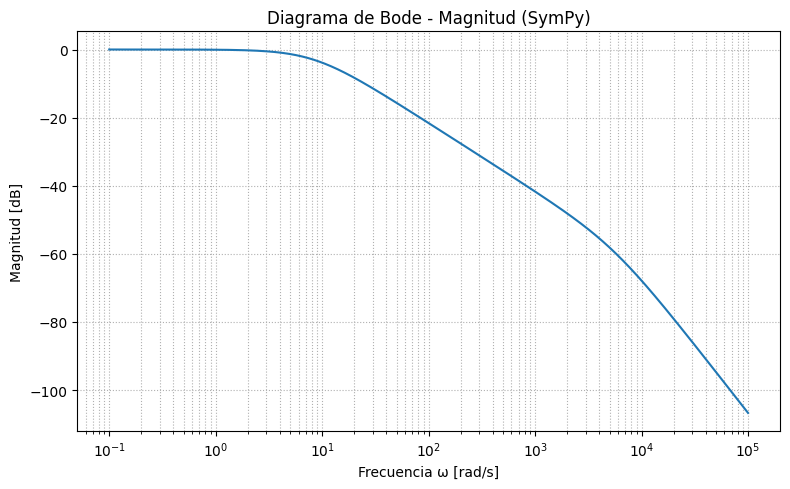

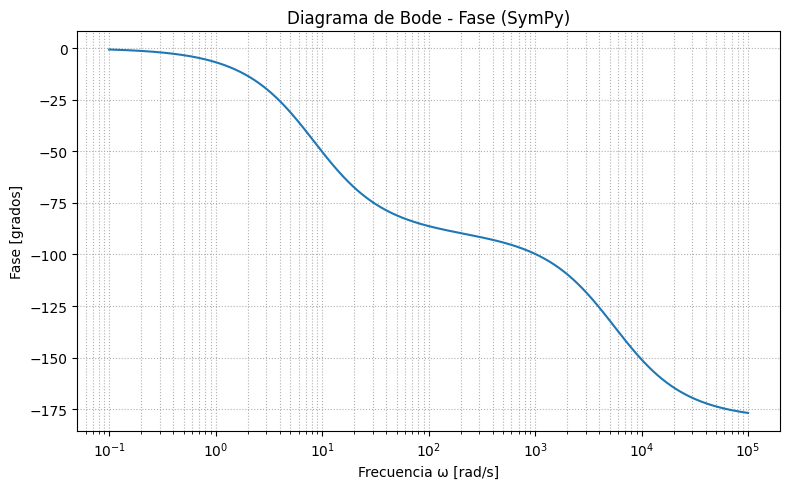

In [ ]:
import numpy as np
import sympy as sym
from sympy.abc import s
import matplotlib.pyplot as plt

# Parámetros del circuito
R = 1_000          # ohmios
L = 0.18           # henrios (180 mH)
C = 120e-6         # faradios (120 uF)

# Coeficientes del denominador: LC s^2 + RC s + 1
LC = L * C
RC = R * C

# Crear la función de transferencia simbólica G(s)
num_sym = 1
den_sym = LC*s**2 + RC*s + 1

G = num_sym / den_sym
print("Función de transferencia G(s) =")
sym.pprint(G)

# --- Cálculo simbólico de polos y ceros ---
ceros = sym.solve(sym.Eq(num_sym, 0), s)
polos = sym.solve(sym.Eq(den_sym, 0), s)

print("\nCeros del sistema:", ceros)
print("Polos del sistema:", polos)

# Convertir polos a valores numéricos
polos_eval = [complex(p) for p in polos]

# --- Diagrama de Polos y Ceros ---
plt.figure(figsize=(6, 6))
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

# Graficar polos
plt.scatter([p.real for p in polos_eval],
            [p.imag for p in polos_eval],
            marker='x', s=80, label="Polos")

plt.title("Diagrama de Polos y Ceros (SymPy)")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()

# --- Diagrama de Bode usando evaluación simbólica ---
w = np.logspace(-1, 5, 1000)
G_eval = sym.lambdify(s, G, 'numpy')

# Evaluar magnitud y fase
Hjw = G_eval(1j*w)
mag = 20 * np.log10(np.abs(Hjw))
phase = np.angle(Hjw, deg=True)

# --- Magnitud ---
plt.figure(figsize=(8, 5))
plt.semilogx(w, mag)
plt.title("Diagrama de Bode - Magnitud (SymPy)")
plt.xlabel("Frecuencia ω [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.grid(True, which="both", ls=":")
plt.tight_layout()

# --- Fase ---
plt.figure(figsize=(8, 5))
plt.semilogx(w, phase)
plt.title("Diagrama de Bode - Fase (SymPy)")
plt.xlabel("Frecuencia ω [rad/s]")
plt.ylabel("Fase [grados]")
plt.grid(True, which="both", ls=":")
plt.tight_layout()

plt.show()


# **MODELO DE CONTROL CON SYMPY**


--- Diagrama de Polos y Ceros ---


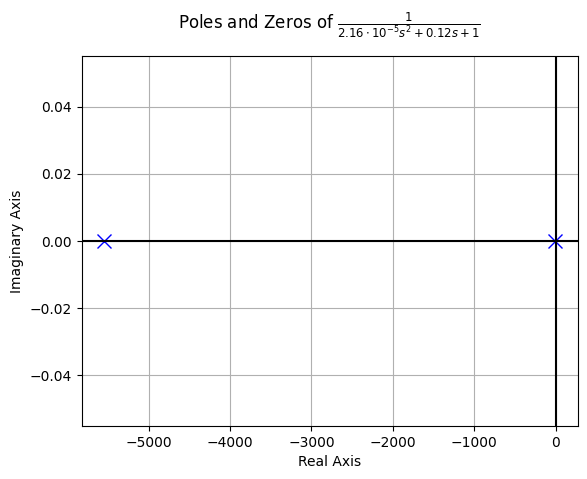


--- Diagrama de Bode ---


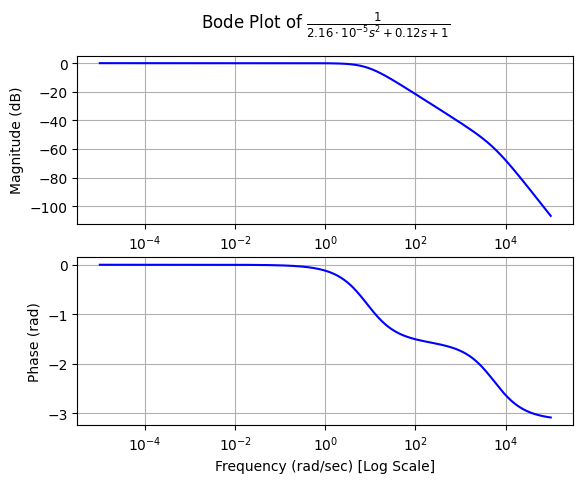


--- Respuesta al Impulso (h(t)) ---


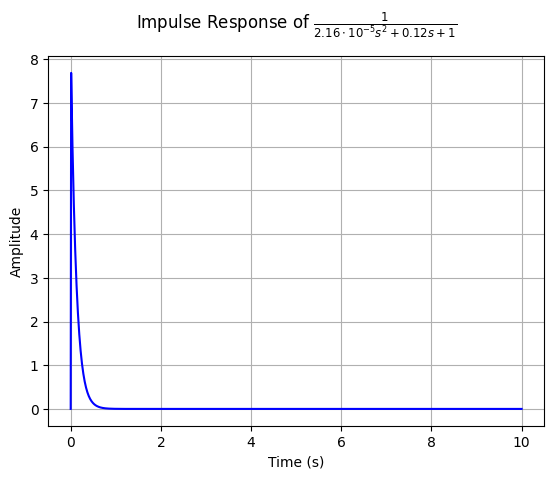


--- Respuesta al Escalón (y(t)) ---


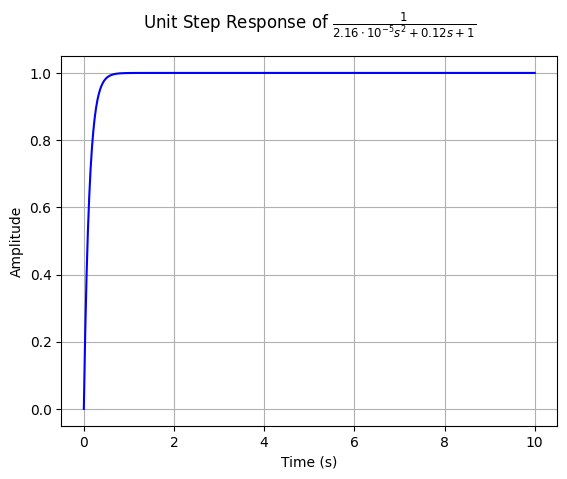

In [ ]:
import sympy as sym
import matplotlib.pyplot as plt
import sympy.physics.control as control

sym.init_printing()

s = sym.symbols('s', complex=True)
t, R, L, C = sym.symbols('t R L C', positive=True)

# --------------------------------------------------------------------------
# PARÁMETROS DEL EJERCICIO ORIGINAL: R = 1kΩ, L = 180mH, C = 120µF
# --------------------------------------------------------------------------
RLC_Ejercicio = {R: 1000, L: 0.180, C: 120e-6}
# Usamos notación científica (e-6) para C

# Definición de la Función de Transferencia H(s) para un filtro pasa-bajos
# H(s) = Vo(s)/Vi(s) = 1 / (LC*s**2 + RC*s + 1)
H=control.TransferFunction(1,L*C*s**2 + R*C*s + 1,s)

# Transferencia Evaluada (HRLC)
HRLC=control.TransferFunction(H.num,H.den.subs(RLC_Ejercicio),s)

# --- 1. Diagrama de Polos y Ceros ---
print("\n--- Diagrama de Polos y Ceros ---")
control.pole_zero_plot(HRLC)
# NOTA: Los polos deberían ser -8.33 y -5547, ambos muy cercanos al eje real.

# --- 2. Diagrama de Bode (Magnitud y Fase) ---
print("\n--- Diagrama de Bode ---")
control.bode_plot(HRLC)
# NOTA: La magnitud debe empezar en 0 dB y caer a partir de 8.33 rad/s.

# --- 3. Respuesta al Impulso (h(t)) ---
print("\n--- Respuesta al Impulso (h(t)) ---")
control.impulse_response_plot(HRLC, T_end=1.5)
# T_end=1.5 para visualizar la componente lenta (-8.33)

# --- 4. Respuesta al Escalón (y(t)) ---
print("\n--- Respuesta al Escalón (y(t)) ---")
control.step_response_plot(HRLC, T_end=1.5)

# **EJERCICIO A ENTREGAR CIRCUITO RLC**

H(s) = TransferFunctionContinuous(
array([46296.2962963]),
array([1.00000000e+00, 5.55555556e+03, 4.62962963e+04]),
dt: None
)


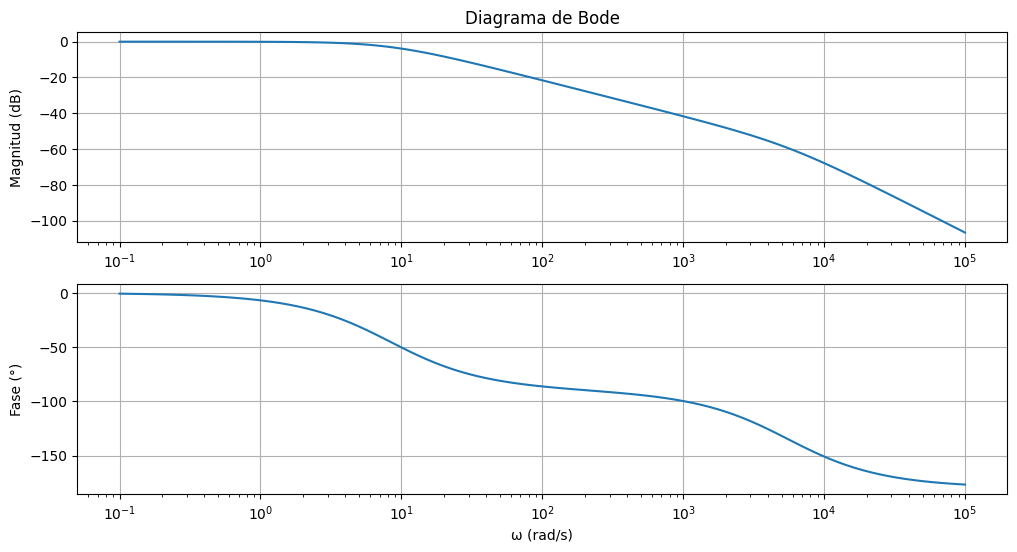

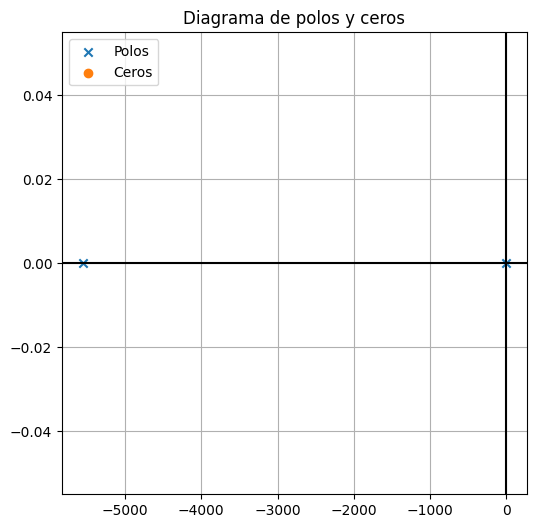

Polos = [-5547.20968458    -8.34587097]
Ceros = []


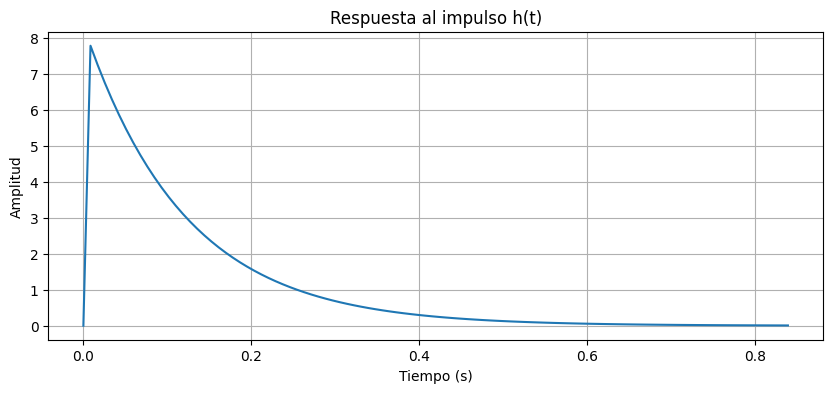

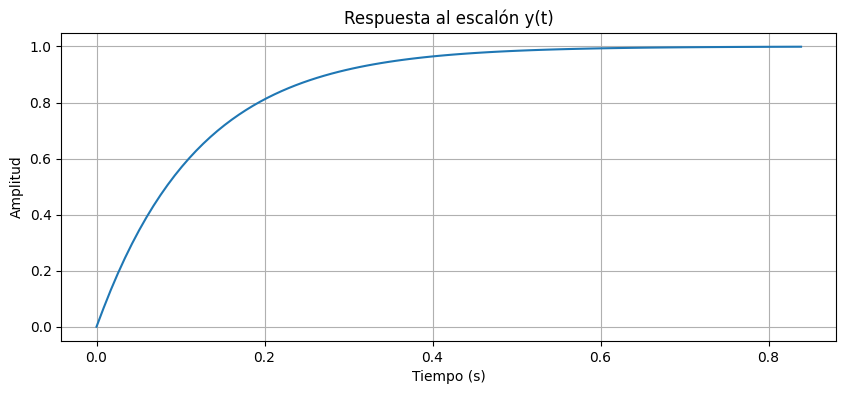

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parámetros
R = 1000
L = 0.18
C = 120e-6

# Función de transferencia H(s)
num = [1]
den = [L*C, R*C, 1]
system = signal.TransferFunction(num, den)

print("H(s) =", system)

# ------------------------------------------
# 1. Bode
# ------------------------------------------
w, mag, phase = signal.bode(system)

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.semilogx(w, mag)
plt.title("Diagrama de Bode")
plt.ylabel("Magnitud (dB)")
plt.grid()

plt.subplot(2,1,2)
plt.semilogx(w, phase)
plt.ylabel("Fase (°)")
plt.xlabel("ω (rad/s)")
plt.grid()
plt.show()

# ------------------------------------------
# 2. Diagrama polos y ceros
# ------------------------------------------
zeros, poles, k = signal.tf2zpk(num, den)

plt.figure(figsize=(6,6))
plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Polos')
plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Ceros')
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid()
plt.title("Diagrama de polos y ceros")
plt.legend()
plt.show()

print("Polos =", poles)
print("Ceros =", zeros)

# ------------------------------------------
# 3. Respuesta al impulso h(t)
# ------------------------------------------
t, h = signal.impulse(system)

plt.figure(figsize=(10,4))
plt.plot(t, h)
plt.grid()
plt.title("Respuesta al impulso h(t)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

# ------------------------------------------
# 4. Respuesta a una entrada: Ejemplo -> escalón
# ------------------------------------------
t, y = signal.step(system)

plt.figure(figsize=(10,4))
plt.plot(t, y)
plt.grid()
plt.title("Respuesta al escalón y(t)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()